# Polars Testing

In [1]:
import polars as pl
import polars.selectors as cs
import re
import duckdb
import plotly_express as px

# Config

In [2]:
base_path = "/Users/rca2t/Repos/Multepal/pv-narrative"
ohco_idx = 4
src_file = f"{base_path}/output/recinos-TOKEN.csv"

# Import TOKEN 

In [3]:
TOKEN = pl.read_csv(src_file)
TOKEN = TOKEN.rename({col:'ohco_' + col for col in TOKEN.columns[:ohco_idx]})
ohco = TOKEN.columns[:ohco_idx]

In [4]:
TOKEN.head()

ohco_parte,ohco_capit,ohco_sent,ohco_token,token_str,token_lemma,token_pos,token_dep,term_str
i64,i64,i64,i64,str,str,str,str,str
0,1,0,0,"""Este""","""este""","""PRON""","""nsubj""","""este"""
0,1,0,1,"""es""","""ser""","""AUX""","""cop""","""es"""
0,1,0,2,"""el""","""el""","""DET""","""det""","""el"""
0,1,0,3,"""principio""","""principio""","""NOUN""","""ROOT""","""principio"""
0,1,0,4,"""de""","""de""","""ADP""","""case""","""de"""


# Create VOCAB

In [68]:
VOCAB = (
    TOKEN
    .group_by('term_str').len().rename({'len':'n'})
    .select(['term_str', 'n'])
    .filter(pl.col('term_str') != '')
    .sort('term_str')
    .with_columns(p = (pl.col('n') / pl.col('n').sum()))
)

In [69]:
VOCAB

term_str,n,p
str,u32,f64
"""a""",840,0.023471
"""abajo""",3,0.000084
"""abandonada""",1,0.000028
"""abandonado""",1,0.000028
"""abandonando""",1,0.000028
…,…,…
"""zotziha""",1,0.000028
"""zotzu""",1,0.000028
"""ztayul""",1,0.000028


In [70]:
vocab = (
    VOCAB
    .select('term_str')
    .to_series()
    .to_list()
)

In [71]:
vocab[:10]

['a',
 'abajo',
 'abandonada',
 'abandonado',
 'abandonando',
 'abandonaran',
 'abandonaron',
 'abarcar',
 'abejas',
 'abejorros']

# Create BOW

In [72]:
BOW = (
    TOKEN
    .filter(pl.col('term_str') != '')
    .group_by(ohco[:2]+['term_str'])
    .len()
    .sort(ohco[:2])
    .rename({'len':'tf'})
)

In [73]:
BOW

ohco_parte,ohco_capit,term_str,tf
i64,i64,str,u32
0,1,"""creado""",1
0,1,"""lado""",1
0,1,"""narracion""",3
0,1,"""manifestacion""",1
0,1,"""ley""",1
…,…,…,…
4,12,"""eran""",6
4,12,"""yacolatam""",1
4,12,"""persona""",1


# Create DTM

In [74]:
DTM = BOW.pivot(index=ohco[:2], values='tf', on='term_str', aggregate_function='first').fill_null(0)
DTM = DTM.select(ohco[:2] + vocab)

In [75]:
DTM

ohco_parte,ohco_capit,a,abajo,abandonada,abandonado,abandonando,abandonaran,abandonaron,abarcar,abejas,abejorros,abertura,abierta,abierto,abismo,aborrecian,abra,abrazaremos,abrazarnos,abrianlas,abriendo,abrieran,abrieron,abrimos,abrir,abrumado,abrumados,absoluto,abuela,abuelita,abuelo,abuelos,abundancia,abundante,aca,acab,…,ya,yac,yacolatam,yaqui,yaquis,yaxcanul,yendo,yendose,yo,yolcuat,ysereis,zacaha,zaccabaha,zaculeu,zancos,zanganos,zapato,zapotes,zaquic,zaquicaz,zaquinimac,zaquinimatziis,zaquiribal,zaquitoc,zaquiya,zarzas,zipacna,zivan,ziyaha,zompopos,zope,zopilote,zotziha,zotzu,ztayul,zuiva,zumbaban
i64,i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,2,0,0,0,0,0,…,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,2,0,0,0,0,0,…,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,3,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4,8,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,9,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,10,25,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,…,2,0,0,0,0,0,0,0,3,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0


In [76]:
VOCAB.filter(pl.col('term_str').str.starts_with("que")).sort('n', descending=True)

term_str,n,p
str,u32,f64
"""que""",951,0.026572
"""querian""",15,0.000419
"""quedo""",10,0.000279
"""quemaron""",10,0.000279
"""queremos""",8,0.000224
…,…,…
"""quequmaha""",1,0.000028
"""querida""",1,0.000028
"""querido""",1,0.000028


# Compute DFIDF

In [77]:
VOCAB = VOCAB.with_columns(df = DTM.select(vocab).cast(pl.Boolean).sum().transpose().to_series())
VOCAB = VOCAB.with_columns(idf = (DTM.height / pl.col('df')).log(base=2))
VOCAB = VOCAB.with_columns(dfidf = pl.col('df') * pl.col('idf'))

In [78]:
VOCAB = VOCAB.with_columns(
    pl.col('dfidf').round(3),
    pl.col('idf').round(3)
)

In [79]:
VOCAB.sort('dfidf').head(10)

term_str,n,p,df,idf,dfidf
str,u32,f64,u32,f64,f64
"""de""",1755,0.049037,46,0.0,0.0
"""el""",916,0.025594,46,0.0,0.0
"""en""",652,0.018218,46,0.0,0.0
"""la""",1118,0.031239,46,0.0,0.0
"""las""",439,0.012266,46,0.0,0.0
"""los""",1198,0.033474,46,0.0,0.0
"""por""",289,0.008075,46,0.0,0.0
"""que""",951,0.026572,46,0.0,0.0
"""se""",693,0.019363,46,0.0,0.0


In [80]:
VOCAB.sort('dfidf').tail(10)

term_str,n,p,df,idf,dfidf
str,u32,f64,u32,f64,f64
"""ixbalanque""",71,0.001984,17,1.436,24.414
"""muchachos""",96,0.002682,17,1.436,24.414
"""muerte""",27,0.000754,17,1.436,24.414
"""nuestro""",24,0.000671,17,1.436,24.414
"""nuevo""",23,0.000643,17,1.436,24.414
"""quien""",24,0.000671,17,1.436,24.414
"""tiempo""",21,0.000587,17,1.436,24.414
"""vinieron""",31,0.000866,17,1.436,24.414
"""vuestra""",41,0.001146,17,1.436,24.414


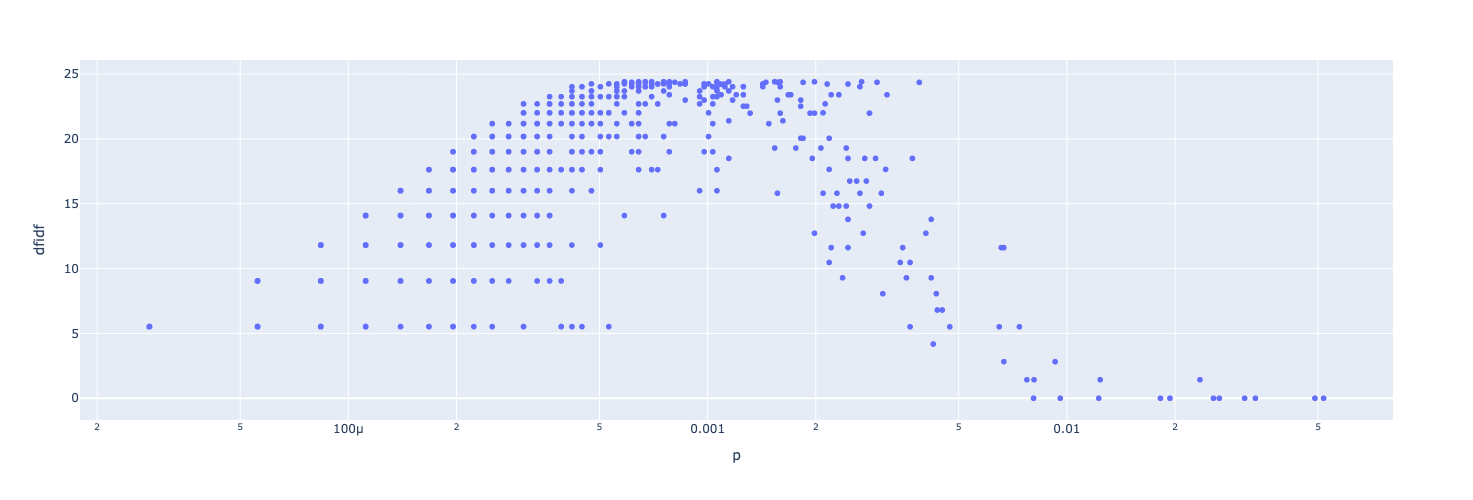

In [81]:
px.scatter(VOCAB, 'p', 'dfidf', log_x=True, hover_name='term_str', height=500, width=600)

In [82]:
VOCAB.filter(pl.col('dfidf') >= 5)

term_str,n,p,df,idf,dfidf
str,u32,f64,u32,f64,f64
"""abajo""",3,0.000084,3,3.939,11.816
"""abandonada""",1,0.000028,1,5.524,5.524
"""abandonado""",1,0.000028,1,5.524,5.524
"""abandonando""",1,0.000028,1,5.524,5.524
"""abandonaran""",1,0.000028,1,5.524,5.524
…,…,…,…,…,…
"""zotziha""",1,0.000028,1,5.524,5.524
"""zotzu""",1,0.000028,1,5.524,5.524
"""ztayul""",1,0.000028,1,5.524,5.524


In [83]:
DTM.select(vocab)

a,abajo,abandonada,abandonado,abandonando,abandonaran,abandonaron,abarcar,abejas,abejorros,abertura,abierta,abierto,abismo,aborrecian,abra,abrazaremos,abrazarnos,abrianlas,abriendo,abrieran,abrieron,abrimos,abrir,abrumado,abrumados,absoluto,abuela,abuelita,abuelo,abuelos,abundancia,abundante,aca,acab,acaba,acababan,…,ya,yac,yacolatam,yaqui,yaquis,yaxcanul,yendo,yendose,yo,yolcuat,ysereis,zacaha,zaccabaha,zaculeu,zancos,zanganos,zapato,zapotes,zaquic,zaquicaz,zaquinimac,zaquinimatziis,zaquiribal,zaquitoc,zaquiya,zarzas,zipacna,zivan,ziyaha,zompopos,zope,zopilote,zotziha,zotzu,ztayul,zuiva,zumbaban
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,2,0,0,0,0,0,0,0,…,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,2,0,0,0,0,0,0,0,…,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,…,2,0,0,0,0,0,0,0,3,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0


In [84]:
(
    VOCAB
    .head(10)
    .style
        .tab_header(title="Vocabulary")
        .tab_stub(rowname_col="term_str")
)

GT(_tbl_data=shape: (10, 6)
┌─────────────┬─────┬──────────┬─────┬───────┬────────┐
│ term_str    ┆ n   ┆ p        ┆ df  ┆ idf   ┆ dfidf  │
│ ---         ┆ --- ┆ ---      ┆ --- ┆ ---   ┆ ---    │
│ str         ┆ u32 ┆ f64      ┆ u32 ┆ f64   ┆ f64    │
╞═════════════╪═════╪══════════╪═════╪═══════╪════════╡
│ a           ┆ 840 ┆ 0.023471 ┆ 45  ┆ 0.032 ┆ 1.427  │
│ abajo       ┆ 3   ┆ 0.000084 ┆ 3   ┆ 3.939 ┆ 11.816 │
│ abandonada  ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abandonado  ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abandonando ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abandonaran ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abandonaron ┆ 2   ┆ 0.000056 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abarcar     ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ abejas      ┆ 3   ┆ 0.000084 ┆ 3   ┆ 3.939 ┆ 11.816 │
│ abejorros   ┆ 4   ┆ 0.000112 ┆ 2   ┆ 4.524 ┆ 9.047  │
└─────────────┴─────┴──────────┴─────┴───────┴────────┘, _body=<great_tables._gt_data.Body object at 0x3356b8530>, _boxhead=Boxhead([ColInfo(var='term_str', type=<ColInfoTypeEnum.stub: 2>, column_label='term_str', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='right', column_width=None), ColInfo(var='p', type=<ColInfoTypeEnum.default: 1>, column_label='p', column_align='right', column_width=None), ColInfo(var='df', type=<ColInfoTypeEnum.default: 1>, column_label='df', column_align='right', column_width=None), ColInfo(var='idf', type=<ColInfoTypeEnum.default: 1>, column_label='idf', column_align='right', column_width=None), ColInfo(var='dfidf', type=<ColInfoTypeEnum.default: 1>, column_label='dfidf', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3363c1130>, _spanners=Spanners([]), _heading=Heading(title='Vocabulary', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x334d34590>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=Tr

In [85]:
(
    VOCAB
    .filter(pl.col('dfidf') >= 5)
    .sample(10)
    .style
        .tab_header(title="Vocabulary Sample")
        .tab_stub(rowname_col="term_str")
)

GT(_tbl_data=shape: (10, 6)
┌────────────┬─────┬──────────┬─────┬───────┬────────┐
│ term_str   ┆ n   ┆ p        ┆ df  ┆ idf   ┆ dfidf  │
│ ---        ┆ --- ┆ ---      ┆ --- ┆ ---   ┆ ---    │
│ str        ┆ u32 ┆ f64      ┆ u32 ┆ f64   ┆ f64    │
╞════════════╪═════╪══════════╪═════╪═══════╪════════╡
│ orador     ┆ 2   ┆ 0.000056 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ pusieran   ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ alguna     ┆ 3   ┆ 0.000084 ┆ 3   ┆ 3.939 ┆ 11.816 │
│ venceremos ┆ 4   ┆ 0.000112 ┆ 3   ┆ 3.939 ┆ 11.816 │
│ amarillo   ┆ 4   ┆ 0.000112 ┆ 4   ┆ 3.524 ┆ 14.094 │
│ novena     ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ muertes    ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ sanos      ┆ 3   ┆ 0.000084 ┆ 2   ┆ 4.524 ┆ 9.047  │
│ cautivo    ┆ 1   ┆ 0.000028 ┆ 1   ┆ 5.524 ┆ 5.524  │
│ caigan     ┆ 2   ┆ 0.000056 ┆ 1   ┆ 5.524 ┆ 5.524  │
└────────────┴─────┴──────────┴─────┴───────┴────────┘, _body=<great_tables._gt_data.Body object at 0x3344e72f0>, _boxhead=Boxhead([ColInfo(var='term_str', type=<ColInfoTypeEnum.stub: 2>, column_label='term_str', column_align='left', column_width=None), ColInfo(var='n', type=<ColInfoTypeEnum.default: 1>, column_label='n', column_align='right', column_width=None), ColInfo(var='p', type=<ColInfoTypeEnum.default: 1>, column_label='p', column_align='right', column_width=None), ColInfo(var='df', type=<ColInfoTypeEnum.default: 1>, column_label='df', column_align='right', column_width=None), ColInfo(var='idf', type=<ColInfoTypeEnum.default: 1>, column_label='idf', column_align='right', column_width=None), ColInfo(var='dfidf', type=<ColInfoTypeEnum.default: 1>, column_label='dfidf', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x3363c1a60>, _spanners=Spanners([]), _heading=Heading(title='Vocabulary Sample', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x3363c1d00>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, categ